<a href="https://colab.research.google.com/github/contreras-juan/Material-Ciencia-de-Datos/blob/main/Deep_Learning/Ejercicios/Soluciones/03_Taller_RNN_LSTM_Solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<h1 style="color: #FECB05; text-align: center;">Solución — Taller práctico: RNN y LSTM</h1>


<h2 style="color: #007ACC;">Autores</h2>

- [Juan Felipe Contreras Alcívar](https://www.linkedin.com/in/juanf-contreras/)

> Solución de referencia de [`03_Taller_RNN_LSTM.ipynb`](../03_Taller_RNN_LSTM.ipynb).
> Los resultados pueden variar ligeramente según TensorFlow/hardware.


---


<h2 style="color: #007ACC;">Tabla de contenido</h2>

- [Instalación e importaciones](#importaciones)
- [Ejercicio 1](#ejercicio-1)
- [Ejercicio 2](#ejercicio-2)
- [Ejercicio 3](#ejercicio-3)
- [Ejercicio 4](#ejercicio-4)
- [Ejercicio 5](#ejercicio-5)
- [Ejercicio 6](#ejercicio-6)
- [Ejercicio 7](#ejercicio-7)
- [Ejercicio 8](#ejercicio-8)
- [Ejercicio 9](#ejercicio-9)
- [Ejercicio integrador](#ejercicio-integrador)


---

<a id="importaciones"></a>
<h2 style="color: #007ACC;">Instalación e importaciones</h2>


In [1]:
# Instalación de librerías necesarias para esta sesión
# (útil en Google Colab o en un entorno nuevo)
%pip install -q numpy pandas matplotlib scikit-learn tensorflow


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout, ConvLSTM2D, Conv2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)


def temporal_split_arrays(*arrays, train_ratio=0.8):
    n = len(arrays[0])
    cut = int(n * train_ratio)
    return [a[:cut] for a in arrays] + [a[cut:] for a in arrays]


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(np.asarray(y_true).ravel(), np.asarray(y_pred).ravel())))


def plot_history(history, title="Curvas de entrenamiento"):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, hist["loss"], label="train loss")
    if "val_loss" in hist:
        plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def make_windows_univariate(series, look_back):
    series = np.asarray(series).astype("float32").ravel()
    X, y = [], []
    for i in range(len(series) - look_back):
        X.append(series[i:i + look_back])
        y.append(series[i + look_back])
    return np.asarray(X).reshape(-1, look_back, 1), np.asarray(y)


def make_windows_multivariate(features, target, look_back):
    features = np.asarray(features, dtype="float32")
    target = np.asarray(target, dtype="float32").ravel()
    assert len(features) == len(target)
    X, y = [], []
    for i in range(len(target) - look_back):
        X.append(features[i:i + look_back])
        y.append(target[i + look_back])
    return np.asarray(X), np.asarray(y)


def mackey_glass(n_points=1200, tau=17, burn_in=200, x0=1.2):
    total = n_points + burn_in + tau + 1
    x = np.full(total, x0, dtype="float32")
    for t in range(tau, total - 1):
        x[t + 1] = x[t] + 0.2 * x[t - tau] / (1.0 + x[t - tau] ** 10) - 0.1 * x[t]
    return x[burn_in + tau: burn_in + tau + n_points]


def fit_lstm(X_train, y_train, units=32, epochs=40, batch_size=32, stacked=False):
    tf.random.set_seed(SEED)
    if stacked:
        model = Sequential([
            LSTM(units, return_sequences=True, input_shape=X_train.shape[1:]),
            Dropout(0.2),
            LSTM(max(units // 2, 8)),
            Dense(1),
        ])
    else:
        model = Sequential([
            LSTM(units, input_shape=X_train.shape[1:]),
            Dense(1),
        ])
    model.compile(optimizer="adam", loss="mse")
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0)],
        verbose=0,
    )
    return model, history


I0000 00:00:1786649917.986984  177744 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786649917.987276  177744 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786649918.010191  177744 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0


I0000 00:00:1786649918.746015  177744 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786649918.746226  177744 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---

<a id="ejercicio-1"></a>
<h2 style="color: #007ACC;">Ejercicio 1. Ventanas multivariadas</h2>


In [3]:
features = np.array([[i, i ** 2] for i in range(15)], dtype="float32")
target = np.arange(15, dtype="float32")
X, y = make_windows_multivariate(features, target, look_back=4)
print("X.shape:", X.shape, "| y.shape:", y.shape)
print("X[0]=\n", X[0], "-> y=", y[0])
print("X[1]=\n", X[1], "-> y=", y[1])
print(
    "Para predecir la temperatura de mañana: target = temperatura; "
    "features = [temperatura, codificación del día del año (sin/cos), ...]."
)


X.shape: (11, 4, 2) | y.shape: (11,)
X[0]=
 [[0. 0.]
 [1. 1.]
 [2. 4.]
 [3. 9.]] -> y= 4.0
X[1]=
 [[ 1.  1.]
 [ 2.  4.]
 [ 3.  9.]
 [ 4. 16.]] -> y= 5.0
Para predecir la temperatura de mañana: target = temperatura; features = [temperatura, codificación del día del año (sin/cos), ...].


---

<a id="ejercicio-2"></a>
<h2 style="color: #007ACC;">Ejercicio 2. Cacería de leakage</h2>


In [4]:
BIRTHS_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-total-female-births.csv"
df_b = pd.read_csv(BIRTHS_URL)
series = df_b["Births"].values.astype("float32").ravel()

print("Errores del pipeline incorrecto:")
print("(1) fit_transform sobre toda la serie: el scaler ve min/max del futuro (leakage).")
print("(2) reshape (-1, 1, L) pone timesteps=1 y features=L; Keras espera (N, timesteps, features)=(N, L, 1).")
print("(3) train_test_split aleatorio rompe el orden temporal y filtra futuro a train.")

split = int(len(series) * 0.8)
train_raw, test_raw = series[:split], series[split:]

scaler_b = MinMaxScaler()
train_scaled = scaler_b.fit_transform(train_raw.reshape(-1, 1)).ravel()
test_scaled = scaler_b.transform(test_raw.reshape(-1, 1)).ravel()

L = 7
trainX, trainY = make_windows_univariate(train_scaled, L)
testX, testY = make_windows_univariate(test_scaled, L)
print("trainX:", trainX.shape, "| testX:", testX.shape)
print("trainY:", trainY.shape, "| testY:", testY.shape)


Errores del pipeline incorrecto:
(1) fit_transform sobre toda la serie: el scaler ve min/max del futuro (leakage).
(2) reshape (-1, 1, L) pone timesteps=1 y features=L; Keras espera (N, timesteps, features)=(N, L, 1).
(3) train_test_split aleatorio rompe el orden temporal y filtra futuro a train.
trainX: (285, 7, 1) | testX: (66, 7, 1)
trainY: (285,) | testY: (66,)


---

<a id="ejercicio-3"></a>
<h2 style="color: #007ACC;">Ejercicio 3. SimpleRNN en Mackey–Glass</h2>


E0000 00:00:1786649919.151736  177744 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1786649919.151997  177869 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1786649919.170130  177744 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argum

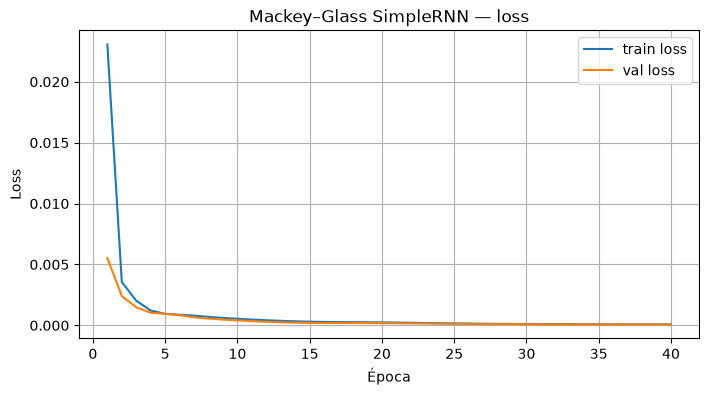

Test RMSE: 0.0082


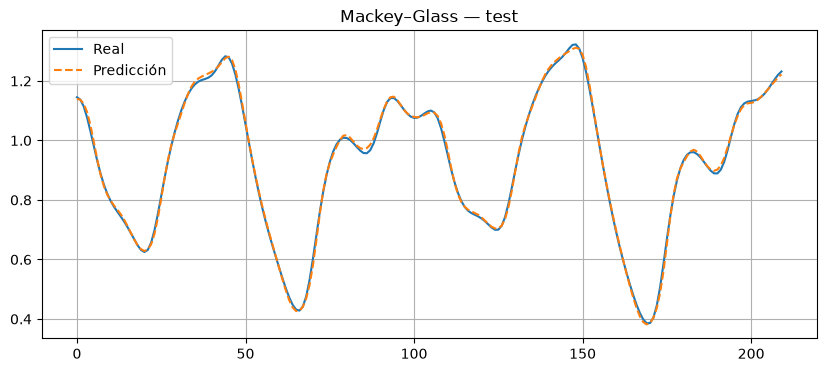

In [5]:
series_mg = mackey_glass(1200)
split = int(len(series_mg) * 0.8)
train_raw, test_raw = series_mg[:split], series_mg[split:]

scaler_mg = MinMaxScaler()
train_s = scaler_mg.fit_transform(train_raw.reshape(-1, 1)).ravel()
test_s = scaler_mg.transform(test_raw.reshape(-1, 1)).ravel()

look_back = 30
X_tr, y_tr = make_windows_univariate(train_s, look_back)
X_te, y_te = make_windows_univariate(test_s, look_back)

tf.random.set_seed(SEED)
model_rnn = Sequential([
    SimpleRNN(48, activation="tanh", input_shape=(look_back, 1)),
    Dense(1),
])
model_rnn.compile(optimizer="adam", loss="mse")
history_rnn = model_rnn.fit(
    X_tr, y_tr,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0)],
    verbose=0,
)
plot_history(history_rnn, "Mackey–Glass SimpleRNN — loss")

y_hat_s = model_rnn.predict(X_te, verbose=0)
y_true = scaler_mg.inverse_transform(y_te.reshape(-1, 1)).ravel()
y_hat = scaler_mg.inverse_transform(y_hat_s).ravel()
print(f"Test RMSE: {rmse(y_true, y_hat):.4f}")

plt.figure(figsize=(10, 4))
plt.plot(y_true, label="Real")
plt.plot(y_hat, "--", label="Predicción")
plt.title("Mackey–Glass — test")
plt.legend()
plt.grid(True)
plt.show()


---

<a id="ejercicio-4"></a>
<h2 style="color: #007ACC;">Ejercicio 4. LSTM en temperaturas diarias</h2>


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


look_back=7 | Test RMSE=2.215


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


look_back=30 | Test RMSE=2.194
Mejor look_back: 30


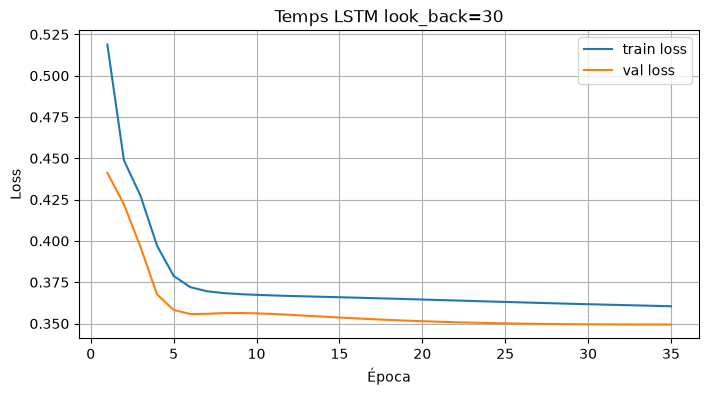

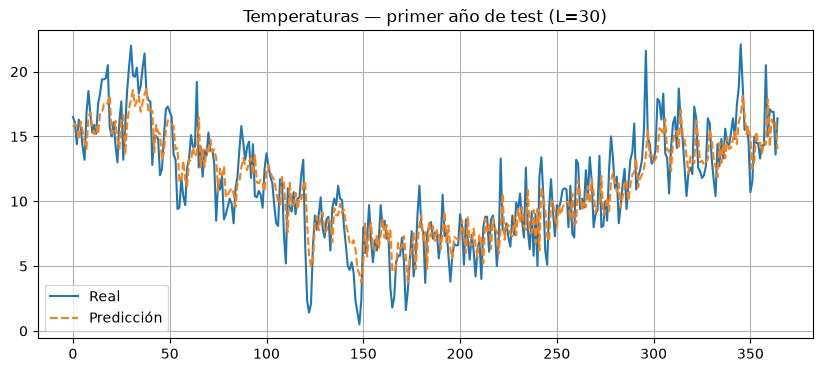

A priori: L=7 captura ciclo semanal; L=30 captura estructura mensual. La estacionalidad anual pediría contextos mucho mayores o features de calendario. El mejor RMSE empírico indica qué memoria corta fue más útil con este presupuesto.


In [6]:
TEMPS_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
temps = pd.read_csv(TEMPS_URL)["Temp"].values.astype("float32").ravel()

split = int(len(temps) * 0.8)
train_raw, test_raw = temps[:split], temps[split:]
scaler_t = StandardScaler()
train_s = scaler_t.fit_transform(train_raw.reshape(-1, 1)).ravel()
test_s = scaler_t.transform(test_raw.reshape(-1, 1)).ravel()


def train_eval_lookback(look_back):
    X_tr, y_tr = make_windows_univariate(train_s, look_back)
    X_te, y_te = make_windows_univariate(test_s, look_back)
    model, history = fit_lstm(X_tr, y_tr, units=32, epochs=35, batch_size=32, stacked=False)
    pred_s = model.predict(X_te, verbose=0)
    y_true = scaler_t.inverse_transform(y_te.reshape(-1, 1)).ravel()
    y_pred = scaler_t.inverse_transform(pred_s).ravel()
    return model, history, y_true, y_pred, rmse(y_true, y_pred)

results = {}
for L in (7, 30):
    model, history, y_true, y_pred, score = train_eval_lookback(L)
    results[L] = dict(model=model, history=history, y_true=y_true, y_pred=y_pred, rmse=score)
    print(f"look_back={L} | Test RMSE={score:.3f}")

best_L = min(results, key=lambda k: results[k]["rmse"])
print("Mejor look_back:", best_L)
plot_history(results[best_L]["history"], f"Temps LSTM look_back={best_L}")

plt.figure(figsize=(10, 4))
plt.plot(results[best_L]["y_true"][:365], label="Real")
plt.plot(results[best_L]["y_pred"][:365], "--", label="Predicción")
plt.title(f"Temperaturas — primer año de test (L={best_L})")
plt.legend()
plt.grid(True)
plt.show()

print(
    "A priori: L=7 captura ciclo semanal; L=30 captura estructura mensual. "
    "La estacionalidad anual pediría contextos mucho mayores o features de calendario. "
    "El mejor RMSE empírico indica qué memoria corta fue más útil con este presupuesto."
)


---

<a id="ejercicio-5"></a>
<h2 style="color: #007ACC;">Ejercicio 5. Multipaso directo vs recursivo</h2>


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RMSE directo : [2.823 2.858 2.829 2.835 2.83  2.847 2.866]
RMSE recursivo: [2.567 2.932 2.955 2.972 2.955 2.983 2.981]


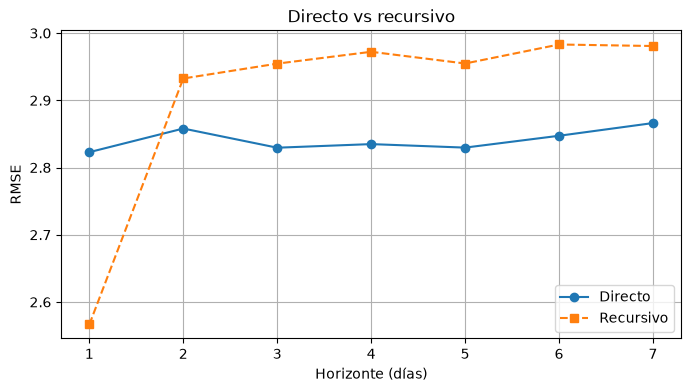

El recursivo suele degradarse antes porque reinyecta sus propios errores: cada paso futuro se condiciona a predicciones previas, no a observaciones reales.


In [7]:
# Submuestra para acelerar
temps_h = temps[:1500]
split = int(len(temps_h) * 0.8)
tr_raw, te_raw = temps_h[:split], temps_h[split:]
sc = StandardScaler()
tr = sc.fit_transform(tr_raw.reshape(-1, 1)).ravel()
te = sc.transform(te_raw.reshape(-1, 1)).ravel()

L, H = 14, 7

def make_multi_output(series, look_back, horizon):
    series = np.asarray(series).astype("float32").ravel()
    X, Y = [], []
    for i in range(len(series) - look_back - horizon + 1):
        X.append(series[i:i + look_back])
        Y.append(series[i + look_back:i + look_back + horizon])
    return np.asarray(X).reshape(-1, look_back, 1), np.asarray(Y)

X_tr_d, Y_tr_d = make_multi_output(tr, L, H)
X_te_d, Y_te_d = make_multi_output(te, L, H)

tf.random.set_seed(SEED)
model_direct = Sequential([
    LSTM(48, input_shape=(L, 1)),
    Dense(H),
])
model_direct.compile(optimizer="adam", loss="mse")
model_direct.fit(
    X_tr_d, Y_tr_d,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0)],
    verbose=0,
)
Y_hat_d = model_direct.predict(X_te_d, verbose=0)

# One-step model for recursive rollout
X_tr_1, y_tr_1 = make_windows_univariate(tr, L)
X_te_1, y_te_1 = make_windows_univariate(te, L)
model_one, _ = fit_lstm(X_tr_1, y_tr_1, units=48, epochs=40, batch_size=32)

def recursive_forecast(model, series_scaled, look_back, horizon):
    """Pronósticos recursivos alineados con make_multi_output sobre series_scaled (test)."""
    preds = []
    for i in range(len(series_scaled) - look_back - horizon + 1):
        window = series_scaled[i:i + look_back].astype("float32").copy()
        out = []
        for _ in range(horizon):
            x = window.reshape(1, look_back, 1)
            yhat = float(model.predict(x, verbose=0).ravel()[0])
            out.append(yhat)
            window = np.append(window[1:], yhat)
        preds.append(out)
    return np.asarray(preds, dtype="float32")

Y_hat_r = recursive_forecast(model_one, te, L, H)

# RMSE por horizonte en escala original
def rmse_by_horizon(Y_true_s, Y_pred_s):
    scores = []
    for h in range(Y_true_s.shape[1]):
        yt = sc.inverse_transform(Y_true_s[:, h].reshape(-1, 1)).ravel()
        yp = sc.inverse_transform(Y_pred_s[:, h].reshape(-1, 1)).ravel()
        scores.append(rmse(yt, yp))
    return scores

rmse_direct = rmse_by_horizon(Y_te_d, Y_hat_d)
rmse_rec = rmse_by_horizon(Y_te_d, Y_hat_r)
print("RMSE directo :", np.round(rmse_direct, 3))
print("RMSE recursivo:", np.round(rmse_rec, 3))

plt.figure(figsize=(8, 4))
plt.plot(range(1, H + 1), rmse_direct, "o-", label="Directo")
plt.plot(range(1, H + 1), rmse_rec, "s--", label="Recursivo")
plt.xlabel("Horizonte (días)")
plt.ylabel("RMSE")
plt.title("Directo vs recursivo")
plt.legend()
plt.grid(True)
plt.show()

print(
    "El recursivo suele degradarse antes porque reinyecta sus propios errores: "
    "cada paso futuro se condiciona a predicciones previas, no a observaciones reales."
)


---

<a id="ejercicio-6"></a>
<h2 style="color: #007ACC;">Ejercicio 6. LSTM apilada y Dropout</h2>


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


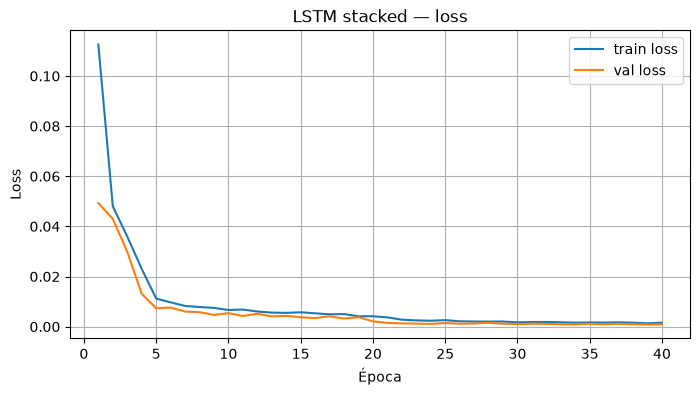

         modelo  test_rmse  params
        shallow     0.0278    4385
stacked+dropout     0.0305    7505
Si stacked no mejora el RMSE de test, la capacidad extra probablemente sobreajustó o el problema no requería esa profundidad con este tamaño de muestra.


In [8]:
# Reusa Mackey–Glass
series_mg = mackey_glass(1200)
split = int(len(series_mg) * 0.8)
scaler_mg = MinMaxScaler()
train_s = scaler_mg.fit_transform(series_mg[:split].reshape(-1, 1)).ravel()
test_s = scaler_mg.transform(series_mg[split:].reshape(-1, 1)).ravel()

look_back = 30
X_tr, y_tr = make_windows_univariate(train_s, look_back)
X_te, y_te = make_windows_univariate(test_s, look_back)

model_sh, _ = fit_lstm(X_tr, y_tr, units=32, epochs=40, stacked=False)
model_st, hist_st = fit_lstm(X_tr, y_tr, units=32, epochs=40, stacked=True)
plot_history(hist_st, "LSTM stacked — loss")

rows = []
for name, model in [("shallow", model_sh), ("stacked+dropout", model_st)]:
    pred = scaler_mg.inverse_transform(model.predict(X_te, verbose=0))
    true = scaler_mg.inverse_transform(y_te.reshape(-1, 1))
    rows.append({
        "modelo": name,
        "test_rmse": round(rmse(true, pred), 4),
        "params": model.count_params(),
    })
print(pd.DataFrame(rows).to_string(index=False))
print(
    "Si stacked no mejora el RMSE de test, la capacidad extra probablemente sobreajustó "
    "o el problema no requería esa profundidad con este tamaño de muestra."
)


---

<a id="ejercicio-7"></a>
<h2 style="color: #007ACC;">Ejercicio 7. Multipaso con baselines y performance</h2>

Basado en la sección multi-step / [Performance](https://www.tensorflow.org/tutorials/structured_data/time_series#performance_3) del tutorial oficial de TensorFlow.


13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Features: ['T (degC)', 'p (mbar)', 'rh (%)'] | shape: (20000, 3)
Train windows: (13953, 24, 3) (13953, 24, 3)
Last     | val MAE=0.4186 | test MAE=0.5221
Repeat   | val MAE=0.4564 | test MAE=0.5008
Dense    | val MAE=0.3943 | test MAE=0.4645


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM     | val MAE=0.3197 | test MAE=0.3892


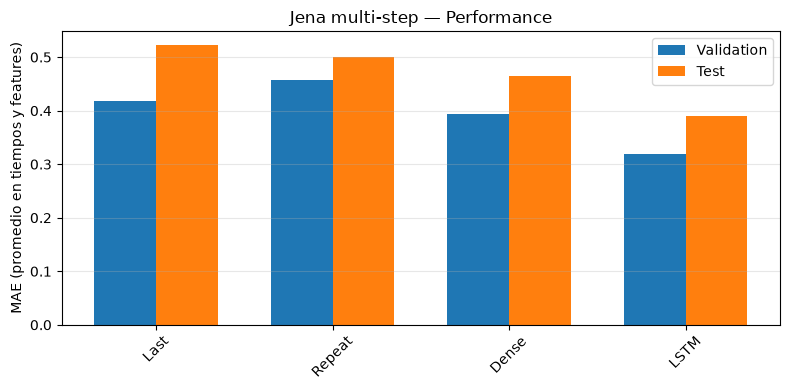


MAE test:
Last    : 0.5221
Repeat  : 0.5008
Dense   : 0.4645
LSTM    : 0.3892


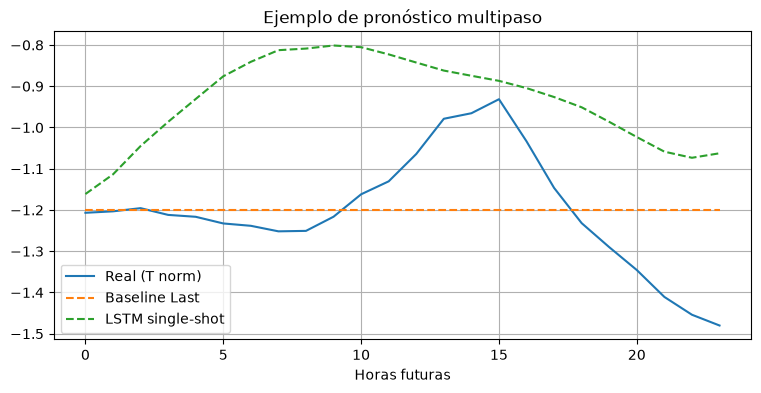

Conclusión típica (como en el tutorial): baselines fuertes (sobre todo Repeat con estacionalidad diaria) pueden acercarse mucho a Dense/LSTM. Si el LSTM no gana de forma clara, la complejidad extra puede no valer la pena en este dataset.


In [9]:
import zipfile
from pathlib import Path as _Path

JENA_ZIP_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = tf.keras.utils.get_file(
    origin=JENA_ZIP_URL,
    fname="jena_climate_2009_2016.csv.zip",
    extract=False,
)
csv_path = _Path(zip_path).with_suffix("").as_posix()  # .../jena_climate_2009_2016.csv
# get_file may extract beside the zip depending on TF version
candidates = [
    csv_path,
    str(_Path(zip_path).parent / "jena_climate_2009_2016.csv"),
]
if not any(_Path(p).exists() for p in candidates):
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(_Path(zip_path).parent)
csv_file = next(p for p in candidates if _Path(p).exists())

df = pd.read_csv(csv_file)
# Fecha como índice y resample horario
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")
df = df.set_index("Date Time").sort_index()
# El CSV original está cada 10 min → 1 h
df_h = df.resample("1h").mean().dropna()

feature_cols = [c for c in ["T (degC)", "p (mbar)", "rh (%)"] if c in df_h.columns]
if len(feature_cols) < 2:
    # fallback por si cambian nombres
    feature_cols = list(df_h.columns[:3])
data = df_h[feature_cols].astype("float32")
# Subconjunto temporal para el taller
data = data.iloc[:20000]
print("Features:", feature_cols, "| shape:", data.shape)

n = len(data)
n_train, n_val = int(n * 0.7), int(n * 0.2)
train_df = data.iloc[:n_train]
val_df = data.iloc[n_train:n_train + n_val]
test_df = data.iloc[n_train + n_val:]

train_mean = train_df.mean()
train_std = train_df.std().replace(0, 1.0)
train_n = ((train_df - train_mean) / train_std).values
val_n = ((val_df - train_mean) / train_std).values
test_n = ((test_df - train_mean) / train_std).values

INPUT_WIDTH, OUT_STEPS = 24, 24
num_features = train_n.shape[1]


def make_multi_step_windows(arr, input_width, out_steps):
    arr = np.asarray(arr, dtype="float32")
    X, Y = [], []
    total = input_width + out_steps
    for i in range(len(arr) - total + 1):
        X.append(arr[i:i + input_width])
        Y.append(arr[i + input_width:i + total])
    return np.asarray(X), np.asarray(Y)


X_tr, Y_tr = make_multi_step_windows(train_n, INPUT_WIDTH, OUT_STEPS)
X_va, Y_va = make_multi_step_windows(val_n, INPUT_WIDTH, OUT_STEPS)
X_te, Y_te = make_multi_step_windows(test_n, INPUT_WIDTH, OUT_STEPS)
print("Train windows:", X_tr.shape, Y_tr.shape)


class MultiStepLastBaseline(tf.keras.Model):
    def call(self, inputs):
        return tf.tile(inputs[:, -1:, :], [1, OUT_STEPS, 1])


class RepeatBaseline(tf.keras.Model):
    def call(self, inputs):
        return inputs


def compile_eval(model, name, train=False, epochs=20):
    model.compile(
        loss=tf.keras.losses.MeanSquaredError(),
        metrics=[tf.keras.metrics.MeanAbsoluteError()],
    )
    if train:
        tf.random.set_seed(SEED)
        model.fit(
            X_tr, Y_tr,
            validation_data=(X_va, Y_va),
            epochs=epochs,
            batch_size=64,
            callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=0)],
            verbose=0,
        )
    val_res = model.evaluate(X_va, Y_va, verbose=0, return_dict=True)
    te_res = model.evaluate(X_te, Y_te, verbose=0, return_dict=True)
    print(f"{name:8s} | val MAE={val_res['mean_absolute_error']:.4f} | test MAE={te_res['mean_absolute_error']:.4f}")
    return val_res, te_res


multi_val_performance, multi_performance = {}, {}

last_baseline = MultiStepLastBaseline()
multi_val_performance["Last"], multi_performance["Last"] = compile_eval(last_baseline, "Last")

repeat_baseline = RepeatBaseline()
multi_val_performance["Repeat"], multi_performance["Repeat"] = compile_eval(repeat_baseline, "Repeat")

tf.random.set_seed(SEED)
multi_dense = tf.keras.Sequential([
    tf.keras.layers.Lambda(lambda x: x[:, -1:, :]),
    Dense(128, activation="relu"),
    Dense(OUT_STEPS * num_features, kernel_initializer=tf.keras.initializers.Zeros()),
    tf.keras.layers.Reshape((OUT_STEPS, num_features)),
])
multi_val_performance["Dense"], multi_performance["Dense"] = compile_eval(
    multi_dense, "Dense", train=True, epochs=25
)

tf.random.set_seed(SEED)
multi_lstm = Sequential([
    LSTM(32, return_sequences=False, input_shape=(INPUT_WIDTH, num_features)),
    Dense(OUT_STEPS * num_features, kernel_initializer=tf.keras.initializers.Zeros()),
    tf.keras.layers.Reshape((OUT_STEPS, num_features)),
])
multi_val_performance["LSTM"], multi_performance["LSTM"] = compile_eval(
    multi_lstm, "LSTM", train=True, epochs=25
)

# Gráfico de performance (estilo tutorial)
metric_name = "mean_absolute_error"
x = np.arange(len(multi_performance))
width = 0.35
val_mae = [v[metric_name] for v in multi_val_performance.values()]
test_mae = [v[metric_name] for v in multi_performance.values()]

plt.figure(figsize=(8, 4))
plt.bar(x - width / 2, val_mae, width, label="Validation")
plt.bar(x + width / 2, test_mae, width, label="Test")
plt.xticks(x, list(multi_performance.keys()), rotation=45)
plt.ylabel("MAE (promedio en tiempos y features)")
plt.title("Jena multi-step — Performance")
plt.legend()
plt.tight_layout()
plt.grid(True, axis="y", alpha=0.3)
plt.show()

print("\nMAE test:")
for name, value in multi_performance.items():
    print(f"{name:8s}: {value[metric_name]:0.4f}")

# Ejemplo visual: una ventana de test (solo temperatura = feature 0)
sample = 0
y_true = Y_te[sample, :, 0]
y_last = last_baseline(X_te[sample:sample+1]).numpy()[0, :, 0]
y_lstm = multi_lstm(X_te[sample:sample+1]).numpy()[0, :, 0]
plt.figure(figsize=(9, 4))
plt.plot(range(OUT_STEPS), y_true, label="Real (T norm)")
plt.plot(range(OUT_STEPS), y_last, "--", label="Baseline Last")
plt.plot(range(OUT_STEPS), y_lstm, "--", label="LSTM single-shot")
plt.xlabel("Horas futuras")
plt.title("Ejemplo de pronóstico multipaso")
plt.legend()
plt.grid(True)
plt.show()

print(
    "Conclusión típica (como en el tutorial): baselines fuertes (sobre todo Repeat con "
    "estacionalidad diaria) pueden acercarse mucho a Dense/LSTM. Si el LSTM no gana de "
    "forma clara, la complejidad extra puede no valer la pena en este dataset."
)


---

<a id="ejercicio-8"></a>
<h2 style="color: #007ACC;">Ejercicio 8. GRU en demanda eléctrica</h2>


trainX: (3492, 14, 1) | testX: (863, 14, 1)


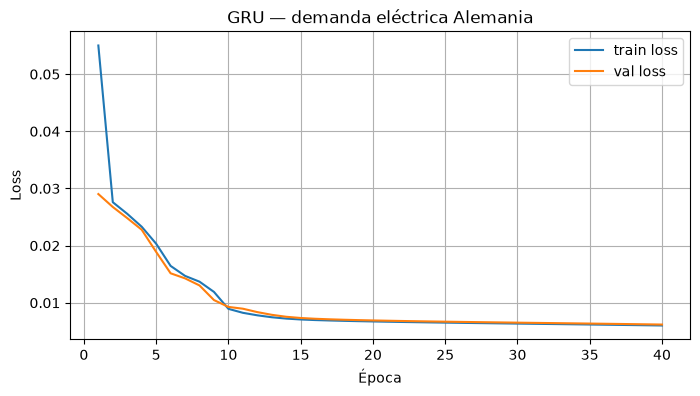

  modelo  test_rmse  params
 GRU(32)     60.157    3393
LSTM(32)     66.878    4385


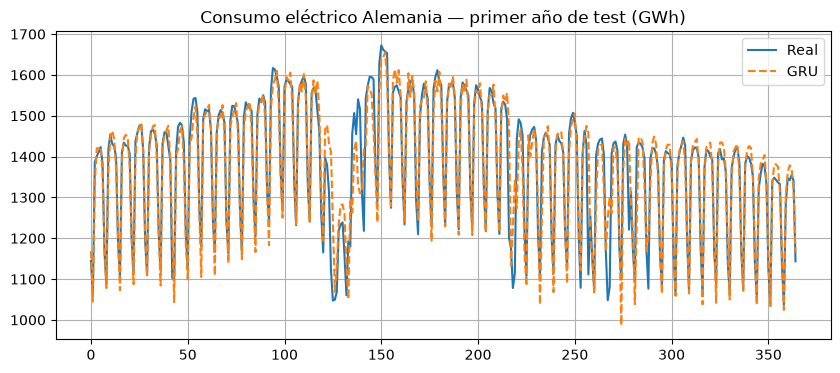

Hay estacionalidad semanal clara (laborales vs fin de semana) y un ciclo anual. GRU suele acercarse a LSTM con menos parámetros; si el RMSE es similar, GRU es la opción más económica. LSTM puede ayudar si el error en picos (invierno) queda alto.


In [1]:
OPSD_URL = "https://raw.githubusercontent.com/jenfly/opsd/master/opsd_germany_daily.csv"
opsd = pd.read_csv(OPSD_URL, parse_dates=["Date"])
series = opsd["Consumption"].values.astype("float32").ravel()

split = int(len(series) * 0.8)
train_raw, test_raw = series[:split], series[split:]
scaler_e = MinMaxScaler()
train_s = scaler_e.fit_transform(train_raw.reshape(-1, 1)).ravel()
test_s = scaler_e.transform(test_raw.reshape(-1, 1)).ravel()

look_back = 14
X_tr, y_tr = make_windows_univariate(train_s, look_back)
X_te, y_te = make_windows_univariate(test_s, look_back)
print("trainX:", X_tr.shape, "| testX:", X_te.shape)


def fit_variant(layer):
    tf.random.set_seed(SEED)
    model = Sequential([layer, Dense(1)])
    model.compile(optimizer="adam", loss="mse")
    history = model.fit(
        X_tr, y_tr,
        validation_split=0.2,
        epochs=40,
        batch_size=32,
        callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0)],
        verbose=0,
    )
    pred_s = model.predict(X_te, verbose=0)
    y_true = scaler_e.inverse_transform(y_te.reshape(-1, 1)).ravel()
    y_pred = scaler_e.inverse_transform(pred_s).ravel()
    return model, history, y_true, y_pred, rmse(y_true, y_pred)


model_gru, hist_gru, y_true, y_gru, rmse_gru = fit_variant(
    GRU(32, activation="tanh", input_shape=(look_back, 1))
)
model_lstm8, hist_lstm8, _, y_lstm8, rmse_lstm8 = fit_variant(
    LSTM(32, activation="tanh", input_shape=(look_back, 1))
)

plot_history(hist_gru, "GRU — demanda eléctrica Alemania")
print(pd.DataFrame([
    {"modelo": "GRU(32)", "test_rmse": round(rmse_gru, 3), "params": model_gru.count_params()},
    {"modelo": "LSTM(32)", "test_rmse": round(rmse_lstm8, 3), "params": model_lstm8.count_params()},
]).to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(y_true[:365], label="Real")
plt.plot(y_gru[:365], "--", label="GRU")
plt.title("Consumo eléctrico Alemania — primer año de test (GWh)")
plt.legend()
plt.grid(True)
plt.show()

print(
    "Hay estacionalidad semanal clara (laborales vs fin de semana) y un ciclo anual. "
    "GRU suele acercarse a LSTM con menos parámetros; si el RMSE es similar, GRU es "
    "la opción más económica. LSTM puede ayudar si el error en picos (invierno) queda alto."
)


---

<a id="ejercicio-9"></a>
<h2 style="color: #007ACC;">Ejercicio 9. ConvLSTM en calidad del aire</h2>


Panel diario: (1461, 9) | 2013-03-01 → 2017-02-28
Campo: (1461, 3, 3)
Ventanas train: (1088, 7, 3, 3, 1)


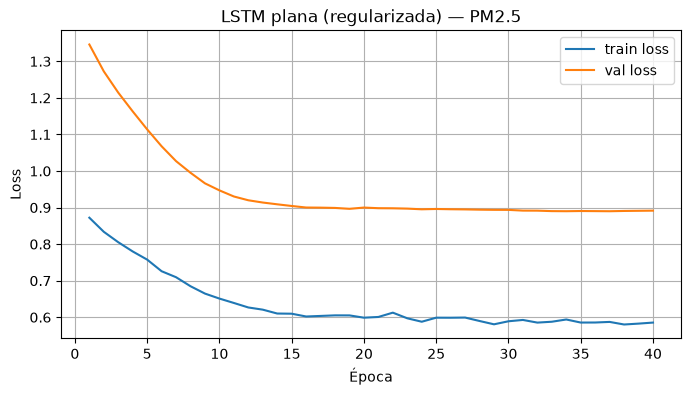

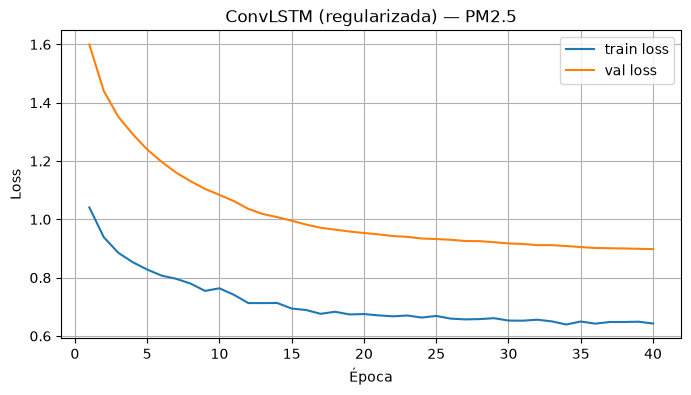

                 modelo  test_rmse  params
  Baseline (último día)     62.981       0
   LSTM plana + dropout     54.617    1817
ConvLSTM2D + dropout/L2     55.696    1193


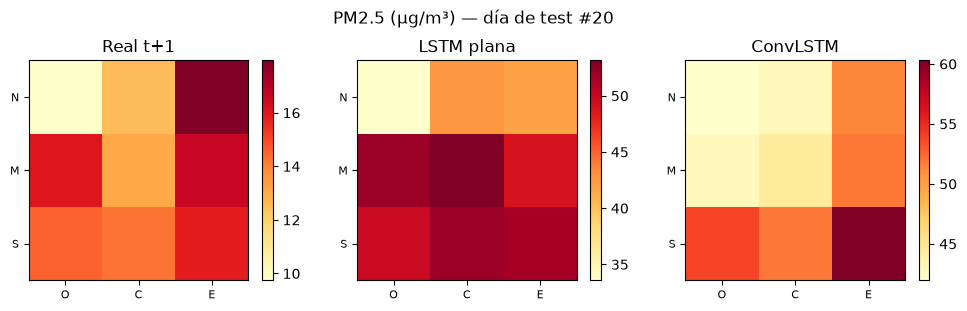

In [1]:
import io
import zipfile

from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

BEIJING_ZIP_URL = "https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip"
GRID = [
    ["Dingling", "Changping", "Huairou"],
    ["Wanliu", "Aotizhongxin", "Shunyi"],
    ["Gucheng", "Tiantan", "Dongsi"],
]

zip_path = tf.keras.utils.get_file(
    origin=BEIJING_ZIP_URL,
    fname="beijing_multisite_aq.zip",
    extract=False,
)
outer = zipfile.ZipFile(zip_path)
inner_name = next(n for n in outer.namelist() if n.endswith(".zip") and "PRSA" in n)
inner = zipfile.ZipFile(io.BytesIO(outer.read(inner_name)))


def daily_pm25(station):
    csv_name = next(
        n for n in inner.namelist()
        if n.endswith(".csv") and station in n
    )
    df = pd.read_csv(inner.open(csv_name))
    df["date"] = pd.to_datetime(df[["year", "month", "day"]])
    return df.groupby("date")["PM2.5"].mean().astype("float32")


panel = pd.concat({st: daily_pm25(st) for row in GRID for st in row}, axis=1)
panel = panel.sort_index().interpolate(limit=3).ffill().bfill()
print("Panel diario:", panel.shape, "|", panel.index.min().date(), "→", panel.index.max().date())

field = np.stack(
    [np.stack([panel[st].values for st in row], axis=1) for row in GRID],
    axis=1,
).astype("float32")
print("Campo:", field.shape)

look_back_g = 7
split = int(len(field) * 0.75)
train_field, test_field = field[:split], field[split:]
mu, sigma = float(train_field.mean()), float(train_field.std())
sigma = sigma if sigma > 0 else 1.0
train_n = (train_field - mu) / sigma
test_n = (test_field - mu) / sigma


def make_grid_windows(arr, look_back):
    X, y = [], []
    for i in range(look_back, len(arr)):
        X.append(arr[i - look_back:i])
        y.append(arr[i])
    return np.asarray(X)[..., np.newaxis], np.asarray(y)[..., np.newaxis]


X_tr_g, y_tr_g = make_grid_windows(train_n, look_back_g)
X_te_g, y_te_g = make_grid_windows(test_n, look_back_g)
H, W = 3, 3
n_zones = H * W
print("Ventanas train:", X_tr_g.shape)

X_tr_flat = X_tr_g.reshape(len(X_tr_g), look_back_g, n_zones)
X_te_flat = X_te_g.reshape(len(X_te_g), look_back_g, n_zones)
y_tr_flat = y_tr_g.reshape(len(y_tr_g), n_zones)

# Regularización: hay ~1100 ventanas; un ConvLSTM ancho sobreajusta fácil.
callbacks_aq = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=0),
]

tf.random.set_seed(SEED)
model_flat = Sequential([
    LSTM(16, dropout=0.2, recurrent_dropout=0.2, input_shape=(look_back_g, n_zones)),
    Dense(n_zones),
])
model_flat.compile(optimizer=Adam(1e-3), loss="mse")
hist_flat = model_flat.fit(
    X_tr_flat, y_tr_flat,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    callbacks=callbacks_aq,
    verbose=0,
)

tf.random.set_seed(SEED)
model_grid = Sequential([
    ConvLSTM2D(
        filters=8,
        kernel_size=(2, 2),
        padding="same",
        return_sequences=False,
        dropout=0.2,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(1e-4),
        input_shape=(look_back_g, H, W, 1),
    ),
    Dropout(0.25),
    Conv2D(filters=1, kernel_size=(1, 1), activation="linear",
           padding="same", kernel_regularizer=l2(1e-4)),
])
model_grid.compile(optimizer=Adam(1e-3), loss="mse")
hist_grid = model_grid.fit(
    X_tr_g, y_tr_g,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    callbacks=callbacks_aq,
    verbose=0,
)

plot_history(hist_flat, "LSTM plana (regularizada) — PM2.5")
plot_history(hist_grid, "ConvLSTM (regularizada) — PM2.5")

pred_flat = model_flat.predict(X_te_flat, verbose=0).reshape(-1, H, W)
pred_grid = model_grid.predict(X_te_g, verbose=0)[..., 0]
true_map = y_te_g[..., 0] * sigma + mu
pred_flat = pred_flat * sigma + mu
pred_grid = pred_grid * sigma + mu
pred_last = X_te_g[:, -1, :, :, 0] * sigma + mu  # baseline: repetir el último día

rmse_last = float(np.sqrt(np.mean((true_map - pred_last) ** 2)))
rmse_flat = float(np.sqrt(np.mean((true_map - pred_flat) ** 2)))
rmse_grid = float(np.sqrt(np.mean((true_map - pred_grid) ** 2)))
print(pd.DataFrame([
    {"modelo": "Baseline (último día)", "test_rmse": round(rmse_last, 3), "params": 0},
    {"modelo": "LSTM plana + dropout", "test_rmse": round(rmse_flat, 3), "params": model_flat.count_params()},
    {"modelo": "ConvLSTM2D + dropout/L2", "test_rmse": round(rmse_grid, 3), "params": model_grid.count_params()},
]).to_string(index=False))

k = min(20, len(true_map) - 1)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, img, title in [
    (axes[0], true_map[k], "Real t+1"),
    (axes[1], pred_flat[k], "LSTM plana"),
    (axes[2], pred_grid[k], "ConvLSTM"),
]:
    im = ax.imshow(img, cmap="YlOrRd")
    ax.set_title(title)
    ax.set_xticks(range(W))
    ax.set_yticks(range(H))
    ax.set_xticklabels(["O", "C", "E"], fontsize=8)
    ax.set_yticklabels(["N", "M", "S"], fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f"PM2.5 (µg/m³) — día de test #{k}")
plt.tight_layout()
plt.show()


**Sobreajuste.** Un ConvLSTM con muchos filtros y BatchNorm, sobre ~1 000 ventanas de una grilla 3×3, memoriza el train con facilidad (PM2.5 tiene colas pesadas y un ciclo estacional fuerte). En esta solución se recorta capacidad y se regulariza:

- menos unidades/filtros (`LSTM(16)`, `ConvLSTM2D(8)`)
- `dropout` y `recurrent_dropout`
- `L2` en los kernels
- se elimina BatchNorm (inestable en mapas tan pequeños)
- `EarlyStopping` + `ReduceLROnPlateau`

El baseline de persistencia (repetir el mapa de ayer) sirve de ancla: si la red no lo mejora de forma clara, el modelo está memorizando ruido, no dinámica espacial.


---

<a id="ejercicio-integrador"></a>
<h2 style="color: #007ACC;">Ejercicio integrador. Producción de leche</h2>


Shape canónica: (114, 12, 1)


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


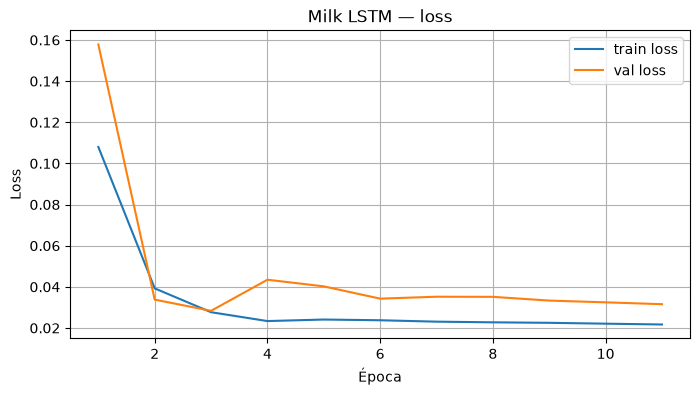

LSTM Train RMSE: 65.71
LSTM Test  RMSE: 62.95
Baseline estacional Test RMSE: 16.07


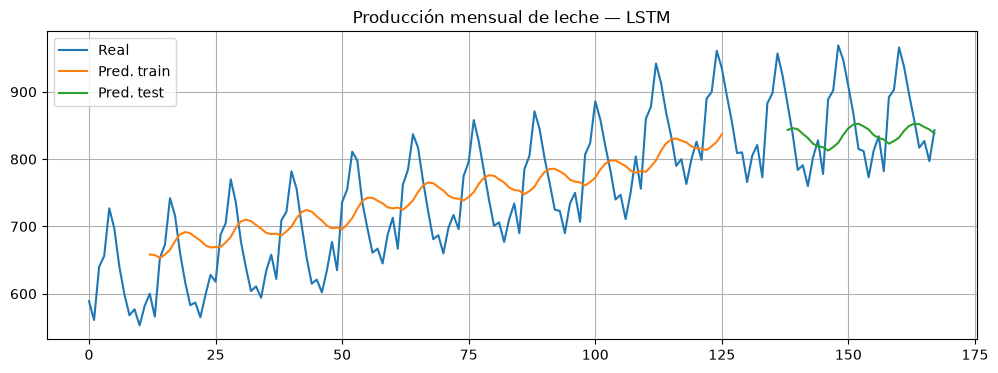

Conclusión: con estacionalidad anual fuerte, el baseline de 12 meses es un rival serio. La LSTM aporta valor si mejora ese RMSE; si no, conviene features de calendario, más datos o modelar residuos sobre el baseline.


In [10]:
MILK_URL = "https://raw.githubusercontent.com/plotly/datasets/master/monthly-milk-production-pounds.csv"
df_m = pd.read_csv(MILK_URL)
# nombre de columna largo
ycol = [c for c in df_m.columns if c != "Month"][0]
milk = df_m[ycol].values.astype("float32").ravel()

split = int(len(milk) * 0.75)
train_raw, test_raw = milk[:split], milk[split:]
scaler_m = MinMaxScaler()
train_s = scaler_m.fit_transform(train_raw.reshape(-1, 1)).ravel()
test_s = scaler_m.transform(test_raw.reshape(-1, 1)).ravel()

look_back = 12
X_tr, y_tr = make_windows_univariate(train_s, look_back)
X_te, y_te = make_windows_univariate(test_s, look_back)
print("Shape canónica:", X_tr.shape)

model_milk, hist_milk = fit_lstm(X_tr, y_tr, units=24, epochs=80, batch_size=8, stacked=False)
plot_history(hist_milk, "Milk LSTM — loss")

train_pred = scaler_m.inverse_transform(model_milk.predict(X_tr, verbose=0))
test_pred = scaler_m.inverse_transform(model_milk.predict(X_te, verbose=0))
train_true = scaler_m.inverse_transform(y_tr.reshape(-1, 1))
test_true = scaler_m.inverse_transform(y_te.reshape(-1, 1))
print(f"LSTM Train RMSE: {rmse(train_true, train_pred):.2f}")
print(f"LSTM Test  RMSE: {rmse(test_true, test_pred):.2f}")

# Baseline estacional: valor de hace 12 meses sobre el tramo test de la serie original
# Para alinear con y_te (que empieza en split+look_back):
test_start = split + look_back
seasonal_pred = milk[test_start - 12: test_start - 12 + len(test_true)]
print(f"Baseline estacional Test RMSE: {rmse(test_true.ravel(), seasonal_pred):.2f}")

train_plot = np.full(len(milk), np.nan)
test_plot = np.full(len(milk), np.nan)
train_plot[look_back:look_back + len(train_pred)] = train_pred.ravel()
test_plot[test_start:test_start + len(test_pred)] = test_pred.ravel()

plt.figure(figsize=(12, 4))
plt.plot(milk, label="Real")
plt.plot(train_plot, label="Pred. train")
plt.plot(test_plot, label="Pred. test")
plt.legend()
plt.title("Producción mensual de leche — LSTM")
plt.grid(True)
plt.show()

print(
    "Conclusión: con estacionalidad anual fuerte, el baseline de 12 meses es un rival serio. "
    "La LSTM aporta valor si mejora ese RMSE; si no, conviene features de calendario, más datos "
    "o modelar residuos sobre el baseline."
)
